In [1]:
!pip install -q kaggle ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 33.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 10.7 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
!kaggle datasets download -d vivek603/vehicle-detection-sample-and-output-videos --unzip

Dataset URL: https://www.kaggle.com/datasets/vivek603/vehicle-detection-sample-and-output-videos
License(s): unknown
100% 242M/242M [00:02<00:00, 87.9MB/s] 



In [4]:
from collections import Counter, defaultdict, deque
from pathlib import Path
from time import perf_counter
import csv

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [ ]:
INPUT_VIDEO = Path("/content/Test Video.mp4")
OUTPUT_DIR = Path("/content/drive/MyDrive/Vision/vision_unit_03/outputs/day_06")

OUTPUT_VIDEO = OUTPUT_DIR / "traffic_analytics_final.mp4"
EVENTS_CSV = OUTPUT_DIR / "crossing_events_final.csv"

MODEL_PATH = "yolo26n.pt"
TRACKER_PATH = "bytetrack.yaml"
LINE_Y_RATIO = 0.82
MAX_CROSSING_GAP = 3

In [24]:
preview_cap = cv2.VideoCapture(str(INPUT_VIDEO))
sucess, preview = preview_cap.read()

source_fps = preview_cap.get(cv2.CAP_PROP_FPS)
preview_cap.release()

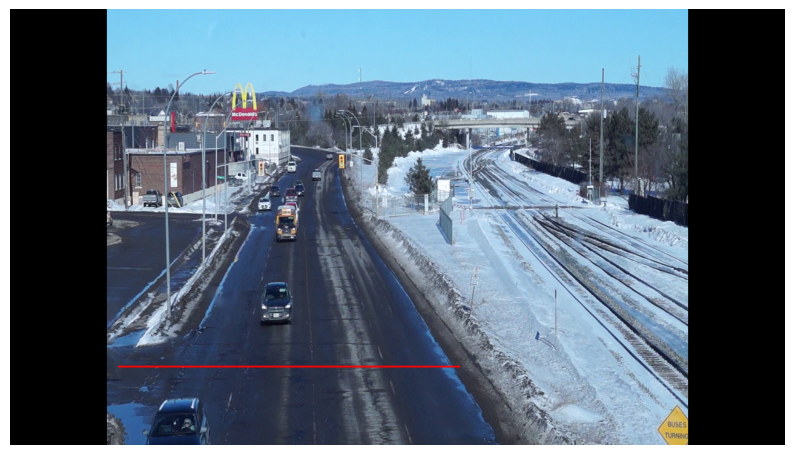

Resolution: 1280x720 | Source FPS: 30.01
Counting line: y=590


In [ ]:
height, width = preview.shape[:2]

line_y = round(height * LINE_Y_RATIO)
line_x1 = round(width * 0.14)
line_x2 = round(width * 0.58)

cv2.line(preview, (line_x1, line_y), (line_x2, line_y), (0, 0, 255), 2)
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(preview, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

print(f"Resolution: {width}x{height} | Source FPS: {source_fps:.2f}")
print(f"Counting line: y={line_y}")

**pipeline**

In [26]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

model = YOLO(MODEL_PATH)
cap = cv2.VideoCapture(str(INPUT_VIDEO))
writer = cv2.VideoWriter(
    str(OUTPUT_VIDEO),
    cv2.VideoWriter_fourcc(*"mp4v"),
    source_fps, (width, height)
)

In [28]:
TARGET_NAMES = ("person", "car", "motorcycle", "bus", "truck")
target_ids = [
    class_id for class_id, name in model.names.items()
    if name in TARGET_NAMES
]

In [ ]:
infer_args = dict(
    device=0,
    imgsz=640,
    rect=False,
    classes=target_ids,
    conf=0.10,
    iou=0.70,
    verbose=False,
    save=False
)

In [29]:
last_point = {}
class_vote = defaultdict(Counter)
trails = defaultdict(lambda: deque(maxlen=30))
counted_ids = set()
counts = Counter()
events = []
frame_times_ms = []
frames_processed = 0

run_start = perf_counter()

try:
    while True:
        frame_start = perf_counter()
        ok, frame = cap.read()
        if not ok:
            break
        
        frame_index = frames_processed
        visible_ids = set()

        results = model.track(
            frame,
            persist=True,
            tracker=TRACKER_PATH,
            **infer_args
        )
        result = results[0]
        boxes = result.boxes
        
        if boxes is not None and boxes.id is not None:
            ids = boxes.id.int().cpu().tolist()
            class_ids = boxes.cls.int().cpu().tolist()
            confidences = boxes.conf.cpu().tolist()
            coordinates = boxes.xyxy.cpu().numpy()
            
            for track_id, class_id, confidence, box in zip(
                ids, class_ids, confidences, coordinates
            ):
                track_id = int(track_id)
                class_name = model.names[int(class_id)]
                x1, y1, x2, y2 = map(float, box)
                
                x = (x1 + x2) / 2
                y = y2
                side = 1 if y > line_y else (-1 if y < line_y else 0)
                
                visible_ids.add(track_id)
                class_vote[track_id][class_name] += 1
                previous = last_point.get(track_id)
                
                if previous is not None and frame_index - previous[0] > MAX_CROSSING_GAP:
                    trails[track_id].clear()
                    
                trails[track_id].append((round(x), round(y)))
                
                if side == 0:
                    continue
                
                if previous is not None:
                    previous_frame, previous_x, previous_y, previous_side = previous
                    gap = frame_index - previous_frame
                    
                    if previous_side != side and gap <= MAX_CROSSING_GAP and track_id not in counted_ids:
                        fraction = (line_y - previous_y) / (y - previous_y)
                        crossing_x = previous_x + fraction * (x - previous_x)
                        
                        if line_x1 <= crossing_x <= line_x2:
                            direction = "up" if side == -1 else "down"
                            event_class = class_vote[track_id].most_common(1)[0][0]

                            counts[(event_class, direction)] += 1
                            counted_ids.add(track_id)

                            events.append({
                                "event_id": len(events) + 1,
                                "frame_index": frame_index,
                                "timestamp_seconds": frame_index / source_fps,
                                "track_id": track_id,
                                "class_name": event_class,
                                "direction": direction,
                                "confidence": float(confidence),
                                "crossing_x": float(crossing_x),
                                "crossing_y": float(line_y),
                                "previous_frame": previous_frame,
                            })

                last_point[track_id] = (frame_index, x, y, side)

        annotated = result.plot()
        cv2.line(
            annotated, (line_x1, line_y), (line_x2, line_y),
            (0, 0, 255), 2
        )
        
        for track_id in visible_ids:
            points = trails[track_id]
            if len(points) >= 2:
                cv2.polylines(
                    annotated,
                    [np.asarray(points, dtype=np.int32).reshape(-1, 1, 2)],
                    False,
                    (255, 255, 255),
                    2,
                )

        labels = [
            f"{name}: U {counts[(name, 'up')]}  D {counts[(name, 'down')]}"
            for name in TARGET_NAMES
        ]
        labels.append(
            f"TOTAL: U {sum(counts[(name, 'up')] for name in TARGET_NAMES)}"
            f"  D {sum(counts[(name, 'down')] for name in TARGET_NAMES)}"
        )
        
        for row, label in enumerate(labels):
            cv2.putText(
                annotated, label, (10, 26 + row * 25),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6,
                (255, 255, 255), 2, cv2.LINE_AA,
            )

        writer.write(annotated)
        frame_times_ms.append((perf_counter() - frame_start) * 1000)
        frames_processed += 1

finally:
    cap.release()
    writer.release()

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 2 packages in 237ms
Prepared 1 package in 43ms
Installed 1 package in 1ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect



In [30]:
total_seconds = perf_counter() - run_start

event_columns = [
    "event_id", "frame_index", "timestamp_seconds", "track_id",
    "class_name", "direction", "confidence",
    "crossing_x", "crossing_y", "previous_frame",
]

with EVENTS_CSV.open("w", newline="", encoding="utf-8") as file:
    csv_writer = csv.DictWriter(file, fieldnames=event_columns)
    csv_writer.writeheader()
    csv_writer.writerows(events)

In [31]:
frame_times_ms = np.asarray(frame_times_ms)
pipeline_fps = frames_processed / total_seconds

print("Frames processed:", frames_processed)
print("Crossing events:", len(events))
print("Mean frame latency (ms):", round(frame_times_ms.mean(), 2))
print("P95 frame latency (ms):", round(np.percentile(frame_times_ms, 95), 2))
print("Pipeline FPS:", round(pipeline_fps, 2))
print("Real-time factor:", round(pipeline_fps / source_fps, 2))
print("Video:", OUTPUT_VIDEO)
print("Events:", EVENTS_CSV)

Frames processed: 2531
Crossing events: 28
Mean frame latency (ms): 32.21
P95 frame latency (ms): 45.82
Pipeline FPS: 30.34
Real-time factor: 1.01
Video: /content/drive/MyDrive/Vision/vision_unit_03/outputs/day_06/traffic_analytics_final.mp4
Events: /content/drive/MyDrive/Vision/vision_unit_03/outputs/day_06/crossing_events_final.csv


In [32]:
display(pd.DataFrame([
    {
        "class_name": name,
        "up": counts[(name, "up")],
        "down": counts[(name, "down")],
    }
    for name in ("person", "car", "motorcycle", "bus", "truck")
]))

,class_name,up,down
0,person,0,0
1,car,11,16
2,motorcycle,0,0
3,bus,0,0
4,truck,1,0
